# TOMOseq data analysis pipeline

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
from scipy.stats import zscore, variation, ttest_ind
from sklearn.preprocessing import normalize, scale, MinMaxScaler
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.axes_grid1 import make_axes_locatable
import random
import multiprocessing
from statsmodels.sandbox.stats.multicomp import multipletests
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import scanpy as sc
import anndata as ad
from venn import venn
%matplotlib inline
import scipy
from collections import defaultdict
import itertools
from matplotlib_venn import venn2

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


Describe funciton to process de data

In [2]:

def accessCountData(list_files, list_id, path):
    """opens the read/transcript/gene counts of each file"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file,idx in zip(list_files,list_id):
        #open each file
        data_frame = pd.read_csv(path+file+'_featurecounts_table_v2.txt', sep='\t', skiprows=[0], index_col=0, header=0, low_memory=False)
        #remove columns info
        data_frame_f=data_frame.drop(axis=1,columns=['Chr', 'Start', 'End', 'Strand', 'Length'])
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[idx] = data_frame_f
        count = count + 1
    
    return dic_dataframes

def accessData(list_files, list_labels):
    """opens the read/transcript/gene counts of each file"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file in list_files:
        #open each file
        data_frame = pd.read_csv(file, sep='\t', compression='gzip', index_col=0)
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[list_labels[count]] = data_frame
        count = count + 1
    
    return dic_dataframes


def plotTotalTranscriptCounts(data_genes,  thr=[4,4,4,4]):
    """plots de total transcript counts per section and the frecuencies. With the variable end we can define a 
    threshold to reduce the number of columns ploted. with thr we set the line for filtering threshold"""
    #create new dictionary to store the total counts
    data_total_log10 = {}
    data_total = {}
    count_threshold = 0

    #subsrtact the keys from the input dictionary
    for key in data_genes:
        name=key.split('_')
        name=' '.join(name)
        #sum all the values in the same column
        data_frame_total = data_genes[key].sum(axis="index")
        #transform to log10, for that we need to add +1 before because log10 of 0 is Na
        modified = data_frame_total+1
        data_frame_total_log10 = pd.DataFrame(np.log10(list(modified)), index=data_frame_total.index.values, columns=['log10'])

        data_frame_total_log10_plot=data_frame_total_log10
        #plot bar plot from the log10 total transcript counts
        data_frame_total_log10_plot.plot(kind='bar', legend=False, figsize=(3, 1.5), color='grey', width=0.75);
        plt.axhline(y=thr[count_threshold], color='r', linestyle='-.', linewidth = 1)
        plt.xlabel('Sections A-P (knee to ankle)', fontsize=7, fontname="Microsoft Sans Serif")
        plt.ylabel(name+' transcript counts (log10)', fontsize=7, fontname="Microsoft Sans Serif")
        plt.yticks(fontsize=7, fontname="Microsoft Sans Serif")
        plt.ylim([0, 7])
        #select everyother 10 labels from the list of column names
        plt.xticks(ticks=np.arange(0, 96, 10), labels=[str(i) for i in range(0,96,10)], rotation='horizontal', fontsize=7, fontname="Microsoft Sans Serif")
        plt.grid(which='major', axis='y', linestyle='--', c='k')
        plt.rcParams['svg.fonttype'] = 'none'
        plt.savefig('Trans-counts_'+key+'.svg', format = 'svg', dpi=300, bbox_inches='tight')   
        plt.show()
        plt.close()
        
        #plot the frequency form the selection
        data_frame_total_log10_plot.plot(kind='hist', legend=False, figsize=(1, 1.5), bins=30, color='grey', orientation='horizontal');
        plt.axhline(y=thr[count_threshold], color='red', linestyle='-.', linewidth = 1)
        plt.ylim([0, 7])
        plt.xlabel('Frequency', fontsize=7, fontname="Microsoft Sans Serif")
        plt.title(name, fontsize=7, fontname="Microsoft Sans Serif")
        plt.xticks(fontsize=7, fontname="Microsoft Sans Serif")
        plt.yticks(fontsize=7, fontname="Microsoft Sans Serif")
        plt.grid(which='major', axis='y', linestyle='--', c='k')
        plt.rcParams['svg.fonttype'] = 'none'
        plt.savefig('Trans-counts_freq_'+key+'.svg', format = 'svg', dpi=300, bbox_inches='tight')   
        plt.savefig('Trans-counts_freq_'+key+'.png', format = 'png', dpi=300, bbox_inches='tight')   
        plt.show()
        plt.close()
        
        #add 1 to the threshold count
        count_threshold = count_threshold + 1
        
        #save the data in new dictionary of total counts
        data_total_log10[key] = data_frame_total_log10
        data_total[key] = data_frame_total
    
    return data_total_log10, data_total

def plotTotalTranscriptCounts2(data_genes, thr=[4, 4, 4, 4]):
    """Plots the total transcript counts per section and the frequencies.
    Each figure contains two subplots side by side sharing the y-axis.
    """
    data_total_log10 = {}
    data_total = {}
    count_threshold = 0
    
    for key in data_genes:
        name = key.replace('_', ' ')
        
        # Sum all values in the same column
        data_frame_total = data_genes[key].sum(axis="index")
        modified = data_frame_total + 1  # Avoid log10(0)
        data_frame_total_log10 = pd.DataFrame(np.log10(modified), index=data_frame_total.index, columns=['log10'])
        
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(4, 2), sharey=True, gridspec_kw={'width_ratios': [4, 1]})
        
        # Bar plot
        data_frame_total_log10.plot(kind='bar', legend=False, ax=axes[0], color='grey', width=0.75)
        axes[0].axhline(y=thr[count_threshold], color='r', linestyle='-.', linewidth=1)
        axes[0].set_xlabel('Sections A-P (knee to ankle)', fontsize=7, fontname="Microsoft Sans Serif")
        axes[0].set_ylabel(f'{name} counts (log10)', fontsize=7, fontname="Microsoft Sans Serif")
        axes[0].set_ylim([0, 7])
        axes[0].set_xticks(np.arange(0, 96, 10))
        axes[0].set_xticklabels([str(i) for i in range(0, 96, 10)], rotation='horizontal', fontsize=7, fontname="Microsoft Sans Serif")
        axes[0].tick_params(axis='both', labelsize=7)
        axes[0].grid(which='major', axis='y', linestyle='--', c='k')
        
        # Histogram
        data_frame_total_log10.plot(kind='hist', legend=False, ax=axes[1], bins=30, color='grey', orientation='horizontal')
        axes[1].axhline(y=thr[count_threshold], color='r', linestyle='-.', linewidth=1)
        axes[1].set_xlabel('Frequency', fontsize=7, fontname="Microsoft Sans Serif")
        axes[1].tick_params(axis='both', labelsize=7)
        axes[1].grid(which='major', axis='y', linestyle='--', c='k')
        axes[1].set_title("")  # Remove title
        
        plt.tight_layout()
        plt.savefig(f'Trans-counts_{key}.svg', format='svg', dpi=300, bbox_inches='tight')
        plt.savefig(f'Trans-counts_{key}.png', format='png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        
        count_threshold += 1
        
        data_total_log10[key] = data_frame_total_log10
        data_total[key] = data_frame_total
    
    return data_total_log10, data_total

def plotDetectedGenes(data_genes, thr):
    """plots de total transcript counts per section and the frecuencies. With the variable end we can define a 
    threshold to reduce the number of columns ploted. with thr we set the line for filtering threshold"""
    #create new dictionary to store the total counts
    data_genes_total = {}
    data_genes_total_log10 = {}
    count_threshold = 0

    #subsrtact the keys from the input dictionary
    for key in data_genes:
        name=key.split('_')
        name=' '.join(name)
        #calculate the number of genes per sections expressed with 2 transcripts or more
        gene_counts = pd.DataFrame(index=data_genes[key].columns.values, columns=['gene_counts'])
        #get the values for each sample
        for column in data_genes[key].columns:
            #column has the label of the column
            #get the value of each gene for each column and count how many genes are expressed (>1)
            #create a counter for the genes
            count = 0
            for element in data_genes[key][column]:
                if element > 1:
                    count = count + 1
            #save the number of genes of the section in a new dataframe of gene_counts
            gene_counts.at[column, 'gene_counts'] = count
        
        #transform to log10, for that we need to add +1 before because log10 of 0 is Na
        gene_counts_modified = gene_counts+1
        
        gene_counts_log10 = pd.DataFrame(np.log10(gene_counts_modified.values.astype(float)), index=gene_counts_modified.index.values, columns=['log10'])
  
        gene_counts_plot=gene_counts_log10
        #plot bar plot from the log10 total transcript counts
        gene_counts_plot.plot(kind='bar', legend=False, figsize=(3, 1.5), color='grey');
        plt.axhline(y=thr[count_threshold], color='black', linestyle='--')
        plt.xlabel('Sections A-P (knee to ankle)', fontsize=7, fontname="Microsoft Sans Serif")
        plt.ylabel('Detected genes', fontsize=7, fontname="Microsoft Sans Serif")
        plt.title(name+" detected genes per slice (log10)", fontsize=7, fontname="Microsoft Sans Serif")
        plt.yticks(fontsize=7, fontname="Microsoft Sans Serif")
        plt.ylim([0, 5])
        #select everyother 10 labels from the list of column names
        plt.xticks(ticks=np.arange(0, 96, 10), labels=[str(i) for i in range(0,96,10)], rotation='horizontal', fontsize=7, fontname="Microsoft Sans Serif")
        plt.grid(which='major', axis='y', linestyle='--', c='k')
        plt.rcParams['svg.fonttype'] = 'none'
        plt.savefig('Gene-counts_'+key+'.svg', format = 'svg', dpi=300, bbox_inches='tight') 
        plt.savefig('Gene-counts_'+key+'.png', format = 'png', dpi=300, bbox_inches='tight') 
        plt.show()
        plt.close()
        #plot the frequency form the selection
        gene_counts_plot.plot(kind='hist', legend=False, figsize=(1, 1.5), bins=30, color='grey', orientation='horizontal');
        
        plt.axhline(y=thr[count_threshold], color='r', linestyle='--')
        plt.ylim([0, 5])
        plt.xlabel('Frequency', fontsize=7, fontname="Microsoft Sans Serif")
        plt.title(name, fontsize=7, fontname="Microsoft Sans Serif")
        plt.xticks(fontsize=7, fontname="Microsoft Sans Serif")
        plt.yticks(fontsize=7, fontname="Microsoft Sans Serif")
        plt.rcParams['svg.fonttype'] = 'none'
        plt.savefig('Gene-counts_freq_'+key+'.svg', format = 'svg', dpi=300, bbox_inches='tight')   
        plt.savefig('Gene-counts_freq_'+key+'.png', format = 'png', dpi=300, bbox_inches='tight')   
        plt.show()
        plt.close()
        
        #add 1 to the threshold count
        count_threshold = count_threshold + 1
        
        #save the data in new dictionary of total counnots
        data_genes_total[key] = gene_counts
        data_genes_total_log10[key] = gene_counts_log10
    
    return data_genes_total, data_genes_total_log10




def tomoseqFilter(row, thr, n):
    condition = False
    #first check that there is 3 sections reaching the thresholod for each gene
    if sum(row>thr)>=3:
        i=0
        #in at lest 3 conecutive sections
        while i<n-2:
            if sum(row[i:i+3]>=thr) >= 3:
                condition = True
                i = n
            else:
                i= i + 1    
    return condition



def removeGmGenes(df):
    g = []
    for idx in df.index:
        if 'Gm' in idx:
            gid = idx.rsplit('Gm')[1].rsplit('_')[0]
            if sum([n in [str(r) for r in range(10)] for n in gid]) == len(gid):
                g.append(idx)
    return df.loc[[idx for idx in df.index if idx not in g]]


def filterMtRiboTOMOseq(dic_data, remove_ribo = False, remove_mt = False, TOMOseq = False, threshold=4):
    """Filter out mithocondrial and noise genes from the datasets"""
    """tomoseq paper: For correlation analysis, all genes expressed at >4 reads in >=3 consecutive sections were 
    selected prior to total-read-normalization."""
    #create new dictionary to store filtered data
    dic_genes_filtered = {}
    #access each dataframe individually
    for key in dic_data:
        dataframe = dic_data[key]
        #remove problematic genes
        genes = ['ERCC', 'Kcnq1ot1', 'Mir5109', 'Lars2', 'Malat1', 'Rn45s', 'Rpl', 'Rps', 'Rik_']
        exclude_genes_index = []
        for index in dataframe.index.values: 
            if any(exclude in index for exclude in genes):
                exclude_genes_index.append(index) 
        #we can filter out the genes using their index names we foudn previusly
        dataframe_filtered_s1 = dataframe.drop(exclude_genes_index)
        
        if remove_ribo == True:
            #select from the gene_info df the rows with chr MT
            ribo_index = []
            for gene_name in dataframe_filtered_s1.index:
                if 'n-' in gene_name or 'Rn5' in gene_name or 'Rn7' in gene_name or 'CT010467.1' in gene_name:
                    ribo_index.append(gene_name)
            #we can filter out the MT genes using their index names
            dataframe_filtered_s2 = dataframe_filtered_s1.drop(ribo_index)
            print('Ribo genes removed')
        if remove_ribo == False:
            dataframe_filtered_s2 = dataframe_filtered_s1
            print('Ribo genes NOT removed')
            
        if remove_mt == True:
            #select from the gene_info df the rows with chr MT
            mt_index = []
            for gene_name in dataframe_filtered_s2.index:
                if gene_name.startswith('mt-'):
                    mt_index.append(gene_name)
            #we can filter out the MT genes using their index names
            dataframe_filtered_s3 = dataframe_filtered_s2.drop(mt_index)
            print('MT genes removed')
        if remove_mt == False:
            dataframe_filtered_s3 = dataframe_filtered_s2
            print('MT genes NOT removed')
            
        if TOMOseq == False:
            dataframe_filtered_s4 = dataframe_filtered_s3
            print('No TOMOseq filtering')
        if TOMOseq == True:
            #make a new dataframe to save TOMOseq filtration
            dataframe_filtered_s4 = pd.DataFrame(columns=dataframe_filtered_s3.columns)
            #go through the dataframe rows to select the ones that have more than X transcripts in at least 3 consecutive sections
            n_sections = len(dataframe_filtered_s3.columns)

            new_data = dataframe_filtered_s3.apply(tomoseqFilter, axis=1, result_type='reduce', args=(threshold, n_sections))
            
            idx_list=[]
            for index in new_data.index:
                if new_data.loc[index]:
                    idx_list.append(index)
            
            dataframe_filtered_s4 = dataframe_filtered_s3.loc[idx_list]
            print('TOMOseq filtering')
            
        #remove Gm genes using Anna's formula
        dataframe_filtered_s5 = removeGmGenes(dataframe_filtered_s4)
        #save the filtered dataframe into the new dictionary
        dic_genes_filtered[key] = dataframe_filtered_s5
    
    return dic_genes_filtered


def normalizeTo(dic_data, factor):
    """Normalize to median
    1. divide by the total reads in each column
    2. multiply by normalization factor"""
    #make a dictionary to store the normalized datasets
    dic_normal = {}
    #Get each dataframe
    for key in dic_data:
        #get the total transcript counts per section
        data_frame_total = dic_data[key].sum(axis='index')
        #divide each section by the total of the section
        data_frame_normal_s1 = dic_data[key].divide(data_frame_total, axis='columns')
        #multiply by the meadian value 
        data_frame_normal = data_frame_normal_s1.multiply(factor)
        #save the dataframe to the dictionary
        dic_normal[key] = data_frame_normal
    
    return dic_normal



def saveCSV(dic_data, label):
    """Save dataframes inside dictionary to csv files"""
    for key in dic_data:
        dic_data[key].to_csv(key+'_'+label+'.tsv.gz', sep='\t', compression='gzip')
    
    return print('Files saved')




## 4- Differential expression analysis

In [3]:
#access de data
#Create a variable list with the file names and one with the labels to use as dictionary keys
path = ''
file_names = [path + 'Muscle_1_genes.t.t.counts_filtered.tsv.gz', 
             path + 'Muscle_2_genes.t.t.counts_filtered.tsv.gz',
              path + 'Muscle_3_genes.t.t.counts_filtered.tsv.gz', 
             path + 'Muscle_4_genes.t.t.counts_filtered.tsv.gz']
labels = ['Female_1', 'Female_2', 'Male_1', 'Male_2']

#use accessData() function to obtain a dictonary with each dataset with labels as key
data = accessData(file_names, labels)
data['Female_1']

,001,002,003,004,005,006,007,008,009,010,...,028,029,030,031,032,033,034,035,036,037
new_gene,,,,,,,,,,,,,,,,,,,,,
ENSMUSG00000000001_Gnai3_ProteinCoding,0.000000,0.000000,1.000000,1.000000,0.000000,2.000244,0.000000,3.000733,0.000000,0.00000,...,4.001466,3.000733,0.000000,1.00000,2.000244,2.000244,2.000244,0.000000,0.000000,0.000000
ENSMUSG00000000028_Cdc45_ProteinCoding,0.000000,0.000000,0.000000,2.000244,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
ENSMUSG00000000031_H19_lincRNA,186.144646,239.860345,478.882342,971.531232,844.238537,1514.246311,1404.302983,1143.685348,1022.550266,849.15658,...,636.994004,1788.029618,398.750438,245.16471,1003.343572,688.717424,414.209340,361.448546,266.451141,151.759125
ENSMUSG00000000037_Scml2_ProteinCoding,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.00000,...,1.000000,0.000000,0.000000,0.00000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
ENSMUSG00000000049_Apoh_ProteinCoding,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.00000,...,1.000000,1.000000,0.000000,0.00000,2.000244,1.000000,0.000000,1.000000,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000118623_AL935121.1_ProteinCoding,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000118638_AL805980.1_ProteinCoding,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000118652_AL645799.1_lincRNA,0.000000,1.000000,0.000000,2.000244,0.000000,2.000244,1.000000,1.000000,0.000000,0.00000,...,0.000000,2.000244,0.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [4]:
#Find mitocondrial and ribosomal genes which are expressed equally across sections. Therefore not interesting
data_filtered_s1 = filterMtRiboTOMOseq(data, remove_ribo = True, remove_mt = False, TOMOseq = False, threshold=4)
data_filtered_s1

Ribo genes removed
MT genes NOT removed
No TOMOseq filtering
Ribo genes removed
MT genes NOT removed
No TOMOseq filtering
Ribo genes removed
MT genes NOT removed
No TOMOseq filtering
Ribo genes removed
MT genes NOT removed
No TOMOseq filtering


{'Female_1':                                                     001         002  \
 new_gene                                                              
 ENSMUSG00000000001_Gnai3_ProteinCoding         0.000000    0.000000   
 ENSMUSG00000000028_Cdc45_ProteinCoding         0.000000    0.000000   
 ENSMUSG00000000031_H19_lincRNA               186.144646  239.860345   
 ENSMUSG00000000037_Scml2_ProteinCoding         0.000000    0.000000   
 ENSMUSG00000000049_Apoh_ProteinCoding          0.000000    0.000000   
 ...                                                 ...         ...   
 ENSMUSG00000118623_AL935121.1_ProteinCoding    0.000000    0.000000   
 ENSMUSG00000118638_AL805980.1_ProteinCoding    0.000000    0.000000   
 ENSMUSG00000118652_AL645799.1_lincRNA          0.000000    1.000000   
 ENSMUSG00000118653_AC159819.1_ProteinCoding    0.000000    0.000000   
 ENSMUSG00000118659_AC158307.1_lincRNA          0.000000    0.000000   
 
                                                  

In [5]:
for key in data_filtered_s1:
    print(np.mean(data_filtered_s1[key].sum()))

470141.05784187187
346860.6875218405
560053.6226877717
514052.83430308296


In [6]:
data_filtered_s1=data

In [7]:
#normalize datasets
data_genes_filtered_normal = normalizeTo(data_filtered_s1, factor=500000)
data_genes_filtered_normal['Female_1']

,001,002,003,004,005,006,007,008,009,010,...,028,029,030,031,032,033,034,035,036,037
new_gene,,,,,,,,,,,,,,,,,,,,,
ENSMUSG00000000001_Gnai3_ProteinCoding,0.000000,0.000000,1.698286,0.808798,0.000000,1.488948,0.000000,2.625874,0.000000,0.000000,...,4.389187,1.458663,0.000000,2.580330,1.478881,1.544135,2.562324,0.000000,0.000000,0.000000
ENSMUSG00000000028_Cdc45_ProteinCoding,0.000000,0.000000,0.000000,1.617793,0.000000,0.744383,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.281006,0.000000,0.000000,0.000000
ENSMUSG00000000031_H19_lincRNA,561.318165,622.419297,813.279233,785.772269,890.518909,1127.179421,1270.107524,1000.813461,1006.759023,1281.276043,...,698.715378,869.165314,536.690979,632.605747,741.822223,531.671520,530.604514,361.901695,763.499345,467.397491
ENSMUSG00000000037_Scml2_ProteinCoding,0.000000,0.000000,0.000000,0.000000,1.054819,0.744383,0.000000,0.875078,0.000000,0.000000,...,1.096895,0.000000,0.000000,0.000000,0.739350,0.000000,1.281006,0.000000,0.000000,0.000000
ENSMUSG00000000049_Apoh_ProteinCoding,0.000000,0.000000,0.000000,0.808798,1.054819,0.000000,0.000000,0.000000,0.000000,1.508881,...,1.096895,0.486102,0.000000,0.000000,1.478881,0.771973,0.000000,1.001254,0.000000,3.079864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000118623_AL935121.1_ProteinCoding,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000118638_AL805980.1_ProteinCoding,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000118652_AL645799.1_lincRNA,0.000000,2.594924,0.000000,1.617793,0.000000,1.488948,0.904440,0.875078,0.000000,0.000000,...,0.000000,0.972323,0.000000,0.000000,0.739350,0.000000,0.000000,0.000000,0.000000,0.000000


In [8]:
with open('background_genes.txt', 'w') as f:
    for index in set(list(data_genes_filtered_normal['Female_1'].index)+list(data_genes_filtered_normal['Female_2'].index)+list(data_genes_filtered_normal['Male_1'].index)+list(data_genes_filtered_normal['Male_2'].index)):
        line=index.split("_")[1]
        f.write(f"{line}\n")
        #print(index.split("_")[1])


In [9]:
# list of muscles and dataframes
muscle_dfs = {"Female_1": data_genes_filtered_normal['Female_1'], "Female_2": data_genes_filtered_normal['Female_2'], "Male_1": data_genes_filtered_normal['Male_1'], "Male_2": data_genes_filtered_normal['Male_2']}

long_df_list = []

for muscle_name, df in muscle_dfs.items():
    df_reset = df.reset_index().melt(id_vars='new_gene', var_name='Section', value_name='Expression')
    df_reset['Muscle'] = muscle_name
    long_df_list.append(df_reset)

long_df = pd.concat(long_df_list, ignore_index=True)
long_df

,new_gene,Section,Expression,Muscle
0,ENSMUSG00000000001_Gnai3_ProteinCoding,001,0.000000,Female_1
1,ENSMUSG00000000028_Cdc45_ProteinCoding,001,0.000000,Female_1
2,ENSMUSG00000000031_H19_lincRNA,001,561.318165,Female_1
3,ENSMUSG00000000037_Scml2_ProteinCoding,001,0.000000,Female_1
4,ENSMUSG00000000049_Apoh_ProteinCoding,001,0.000000,Female_1
...,...,...,...,...
3189313,ENSMUSG00000118506_1700094D03Rik_ProteinCoding,043,0.000000,Male_2
3189314,ENSMUSG00000118537_Shld3_ProteinCoding,043,0.000000,Male_2
3189315,ENSMUSG00000118559_A930007A09Rik_ProteinCoding,043,0.000000,Male_2
3189316,ENSMUSG00000118614_AC107703.1_lincRNA,043,0.000000,Male_2


In [10]:
muscles = list(muscle_dfs.keys())
pairwise_combos = list(itertools.combinations(muscles, 2))

# Union of all genes across muscles
all_genes = pd.Index(sorted(set().union(*[df.index for df in muscle_dfs.values()])))

results_list = []

for m1, m2 in pairwise_combos:
    df1 = muscle_dfs[m1].reindex(all_genes, fill_value=0)
    df2 = muscle_dfs[m2].reindex(all_genes, fill_value=0)
    
    # Remove genes that are zero in both muscles
    nonzero_mask = ~((df1.sum(axis=1) == 0) & (df2.sum(axis=1) == 0))
    df1 = df1[nonzero_mask]
    df2 = df2[nonzero_mask]

    # Log2 fold change with pseudocount
    log2fc = np.log2(df1.mean(axis=1) + 1) - np.log2(df2.mean(axis=1) + 1)

    # Welch's t-test
    t_stat, pvals = ttest_ind(df2.values, df1.values, axis=1, equal_var=False)

    pair_df = pd.DataFrame({
        'Gene': df1.index,
        'Muscle1': m1,
        'Muscle2': m2,
        'Log2FC': log2fc.values,
        'pvalue': pvals
    })

    results_list.append(pair_df)
# Combine all results
results_df = pd.concat(results_list, ignore_index=True)

# FDR correction
results_df['adj_pvalue'] = multipletests(results_df['pvalue'], method='fdr_bh')[1]
results_df.to_excel('DEG_MvsF.xlsx', index=False)
results_df

,Gene,Muscle1,Muscle2,Log2FC,pvalue,adj_pvalue
0,ENSMUSG00000000001_Gnai3_ProteinCoding,Female_1,Female_2,0.118103,5.241272e-01,6.858741e-01
1,ENSMUSG00000000028_Cdc45_ProteinCoding,Female_1,Female_2,-0.015401,9.043945e-01,9.475057e-01
2,ENSMUSG00000000031_H19_lincRNA,Female_1,Female_2,-0.554769,2.738064e-09,8.189421e-08
3,ENSMUSG00000000037_Scml2_ProteinCoding,Female_1,Female_2,0.118835,2.901347e-01,4.986186e-01
4,ENSMUSG00000000049_Apoh_ProteinCoding,Female_1,Female_2,0.072658,7.119138e-01,8.261049e-01
...,...,...,...,...,...,...
121996,ENSMUSG00000118537_Shld3_ProteinCoding,Male_1,Male_2,0.100457,5.260966e-01,6.875143e-01
121997,ENSMUSG00000118559_A930007A09Rik_ProteinCoding,Male_1,Male_2,-0.040107,3.562737e-01,5.321729e-01
121998,ENSMUSG00000118614_AC107703.1_lincRNA,Male_1,Male_2,-0.025711,3.230373e-01,4.986186e-01
121999,ENSMUSG00000118652_AL645799.1_lincRNA,Male_1,Male_2,0.162327,2.919053e-01,4.986186e-01


In [11]:
for index in results_df.index:
    if 'Setd7' in results_df.loc[index]['Gene']:
        print(results_df.loc[index])

Gene          ENSMUSG00000037111_Setd7_ProteinCoding
Muscle1                                     Female_1
Muscle2                                     Female_2
Log2FC                                     -0.486814
pvalue                                      0.000093
adj_pvalue                                  0.001001
Name: 9642, dtype: object
Gene          ENSMUSG00000037111_Setd7_ProteinCoding
Muscle1                                     Female_1
Muscle2                                       Male_1
Log2FC                                     -0.936502
pvalue                                           0.0
adj_pvalue                                       0.0
Name: 30061, dtype: object
Gene          ENSMUSG00000037111_Setd7_ProteinCoding
Muscle1                                     Female_1
Muscle2                                       Male_2
Log2FC                                     -0.373294
pvalue                                      0.000222
adj_pvalue                                  0.

In [12]:
for index in results_df.index:
    if 'Kdm5d' in results_df.loc[index]['Gene']:
        print(results_df.loc[index])

Gene          ENSMUSG00000056673_Kdm5d_ProteinCoding
Muscle1                                     Female_1
Muscle2                                     Female_2
Log2FC                                     -0.130935
pvalue                                      0.353027
adj_pvalue                                  0.529045
Name: 13949, dtype: object
Gene          ENSMUSG00000056673_Kdm5d_ProteinCoding
Muscle1                                     Female_1
Muscle2                                       Male_1
Log2FC                                     -1.943349
pvalue                                           0.0
adj_pvalue                                       0.0
Name: 34428, dtype: object
Gene          ENSMUSG00000056673_Kdm5d_ProteinCoding
Muscle1                                     Female_1
Muscle2                                       Male_2
Log2FC                                     -2.203926
pvalue                                           0.0
adj_pvalue                                   

In [13]:
for index in results_df.index:
    if 'Setdb2' in results_df.loc[index]['Gene']:
        print(results_df.loc[index])

Gene          ENSMUSG00000071350_Setdb2_ProteinCoding
Muscle1                                      Female_1
Muscle2                                      Female_2
Log2FC                                       0.106527
pvalue                                       0.406095
adj_pvalue                                   0.580985
Name: 15525, dtype: object
Gene          ENSMUSG00000071350_Setdb2_ProteinCoding
Muscle1                                      Female_1
Muscle2                                        Male_1
Log2FC                                      -0.422423
pvalue                                         0.0082
adj_pvalue                                   0.046485
Name: 36035, dtype: object
Gene          ENSMUSG00000071350_Setdb2_ProteinCoding
Muscle1                                      Female_1
Muscle2                                        Male_2
Log2FC                                      -0.365408
pvalue                                       0.050493
adj_pvalue                  

In [14]:
for index in results_df.index:
    if 'H2ac6' in results_df.loc[index]['Gene']:
        print(results_df.loc[index])

Gene          ENSMUSG00000069270_H2ac6_ProteinCoding
Muscle1                                     Female_1
Muscle2                                     Female_2
Log2FC                                      0.012335
pvalue                                        0.7685
adj_pvalue                                  0.864339
Name: 15296, dtype: object
Gene          ENSMUSG00000069270_H2ac6_ProteinCoding
Muscle1                                     Female_1
Muscle2                                       Male_1
Log2FC                                     -0.393233
pvalue                                      0.000765
adj_pvalue                                  0.006268
Name: 35803, dtype: object
Gene          ENSMUSG00000069270_H2ac6_ProteinCoding
Muscle1                                     Female_1
Muscle2                                       Male_2
Log2FC                                     -0.592915
pvalue                                      0.000925
adj_pvalue                                  0

In [15]:
for index in results_df.index:
    if 'Pax7' in results_df.loc[index]['Gene']:
        print(results_df.loc[index])

Gene          ENSMUSG00000028736_Pax7_ProteinCoding
Muscle1                                    Female_1
Muscle2                                    Female_2
Log2FC                                    -0.023617
pvalue                                     0.820427
adj_pvalue                                 0.897685
Name: 6286, dtype: object
Gene          ENSMUSG00000028736_Pax7_ProteinCoding
Muscle1                                    Female_1
Muscle2                                      Male_1
Log2FC                                    -0.435974
pvalue                                     0.002152
adj_pvalue                                 0.015235
Name: 26681, dtype: object
Gene          ENSMUSG00000028736_Pax7_ProteinCoding
Muscle1                                    Female_1
Muscle2                                      Male_2
Log2FC                                    -0.639987
pvalue                                     0.001089
adj_pvalue                                 0.008485
Name: 47239

In [16]:
for index in results_df.index:
    if 'Cxcl10' in results_df.loc[index]['Gene']:
        print(results_df.loc[index])

Gene          ENSMUSG00000034855_Cxcl10_ProteinCoding
Muscle1                                      Female_1
Muscle2                                        Male_1
Log2FC                                      -0.769359
pvalue                                       0.001959
adj_pvalue                                   0.014065
Name: 29389, dtype: object
Gene          ENSMUSG00000034855_Cxcl10_ProteinCoding
Muscle1                                      Female_1
Muscle2                                        Male_2
Log2FC                                      -1.128636
pvalue                                       0.000001
adj_pvalue                                    0.00001
Name: 49940, dtype: object
Gene          ENSMUSG00000034855_Cxcl10_ProteinCoding
Muscle1                                      Female_2
Muscle2                                        Male_1
Log2FC                                      -0.769359
pvalue                                       0.001959
adj_pvalue                  

In [17]:
for index in results_df.index:
    if 'Myh2_' in results_df.loc[index]['Gene']:
        print(results_df.loc[index])

Gene          ENSMUSG00000033196_Myh2_ProteinCoding
Muscle1                                    Female_1
Muscle2                                    Female_2
Log2FC                                      0.17549
pvalue                                     0.204216
adj_pvalue                                 0.453998
Name: 8458, dtype: object
Gene          ENSMUSG00000033196_Myh2_ProteinCoding
Muscle1                                    Female_1
Muscle2                                      Male_1
Log2FC                                     1.731759
pvalue                                          0.0
adj_pvalue                                      0.0
Name: 28867, dtype: object
Gene          ENSMUSG00000033196_Myh2_ProteinCoding
Muscle1                                    Female_1
Muscle2                                      Male_2
Log2FC                                     2.710057
pvalue                                          0.0
adj_pvalue                                      0.0
Name: 49421

In [18]:
for index in results_df.index:
    if 'Myh1_' in results_df.loc[index]['Gene']:
        print(results_df.loc[index])

Gene          ENSMUSG00000056328_Myh1_ProteinCoding
Muscle1                                    Female_1
Muscle2                                    Female_2
Log2FC                                     0.202826
pvalue                                     0.005927
adj_pvalue                                 0.035544
Name: 13902, dtype: object
Gene          ENSMUSG00000056328_Myh1_ProteinCoding
Muscle1                                    Female_1
Muscle2                                      Male_1
Log2FC                                     1.298923
pvalue                                          0.0
adj_pvalue                                      0.0
Name: 34379, dtype: object
Gene          ENSMUSG00000056328_Myh1_ProteinCoding
Muscle1                                    Female_1
Muscle2                                      Male_2
Log2FC                                     1.578845
pvalue                                          0.0
adj_pvalue                                      0.0
Name: 5487

In [19]:
for index in results_df.index:
    if 'Myl3_' in results_df.loc[index]['Gene']:
        print(results_df.loc[index])

Gene          ENSMUSG00000059741_Myl3_ProteinCoding
Muscle1                                    Female_1
Muscle2                                    Female_2
Log2FC                                     1.404372
pvalue                                          0.0
adj_pvalue                                      0.0
Name: 14335, dtype: object
Gene          ENSMUSG00000059741_Myl3_ProteinCoding
Muscle1                                    Female_1
Muscle2                                      Male_1
Log2FC                                     1.407304
pvalue                                          0.0
adj_pvalue                                      0.0
Name: 34823, dtype: object
Gene          ENSMUSG00000059741_Myl3_ProteinCoding
Muscle1                                    Female_1
Muscle2                                      Male_2
Log2FC                                     1.713854
pvalue                                          0.0
adj_pvalue                                      0.0
Name: 5531

In [36]:
for index in results_df.index:
    if 'Atp5e' in results_df.loc[index]['Gene']:
        print(results_df.loc[index])

Gene          ENSMUSG00000016252_Atp5e_ProteinCoding
Muscle1                                     Female_1
Muscle2                                     Female_2
Log2FC                                      0.211357
pvalue                                      0.010252
adj_pvalue                                  0.055693
Name: 1547, dtype: object
Gene          ENSMUSG00000016252_Atp5e_ProteinCoding
Muscle1                                     Female_1
Muscle2                                       Male_1
Log2FC                                      0.673125
pvalue                                           0.0
adj_pvalue                                       0.0
Name: 21933, dtype: object
Gene          ENSMUSG00000016252_Atp5e_ProteinCoding
Muscle1                                     Female_1
Muscle2                                       Male_2
Log2FC                                      1.190395
pvalue                                           0.0
adj_pvalue                                    

In [21]:
pair_df

,Gene,Muscle1,Muscle2,Log2FC,pvalue
0,ENSMUSG00000000001_Gnai3_ProteinCoding,Male_1,Male_2,0.751922,0.000007
1,ENSMUSG00000000003_Pbsn_ProteinCoding,Male_1,Male_2,-0.017988,0.323037
2,ENSMUSG00000000028_Cdc45_ProteinCoding,Male_1,Male_2,0.186991,0.061536
3,ENSMUSG00000000031_H19_lincRNA,Male_1,Male_2,-0.058606,0.542859
4,ENSMUSG00000000037_Scml2_ProteinCoding,Male_1,Male_2,0.136184,0.091918
...,...,...,...,...,...
20146,ENSMUSG00000118537_Shld3_ProteinCoding,Male_1,Male_2,0.100457,0.526097
20147,ENSMUSG00000118559_A930007A09Rik_ProteinCoding,Male_1,Male_2,-0.040107,0.356274
20148,ENSMUSG00000118614_AC107703.1_lincRNA,Male_1,Male_2,-0.025711,0.323037
20149,ENSMUSG00000118652_AL645799.1_lincRNA,Male_1,Male_2,0.162327,0.291905


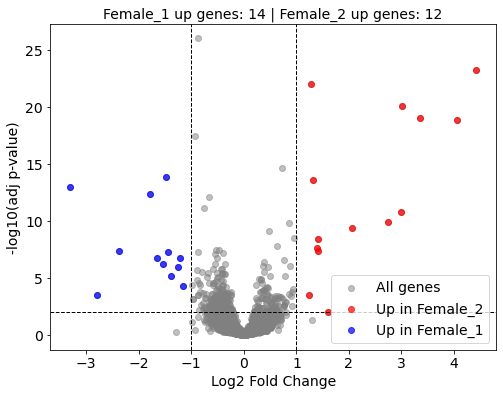

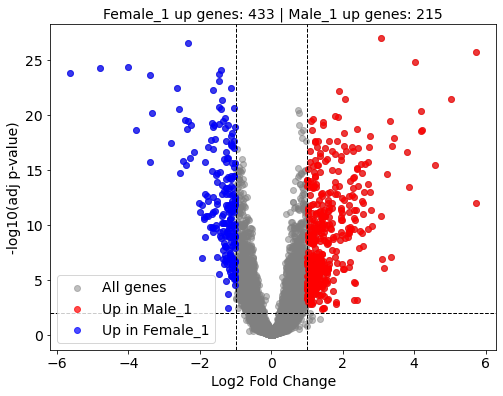

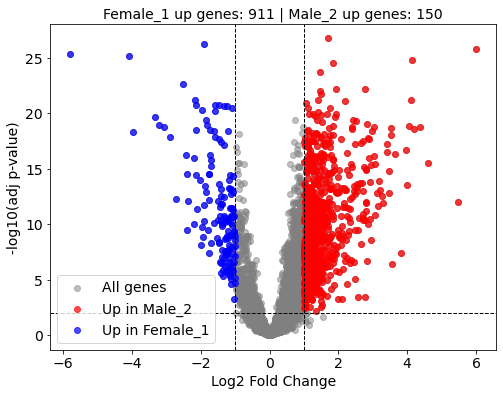

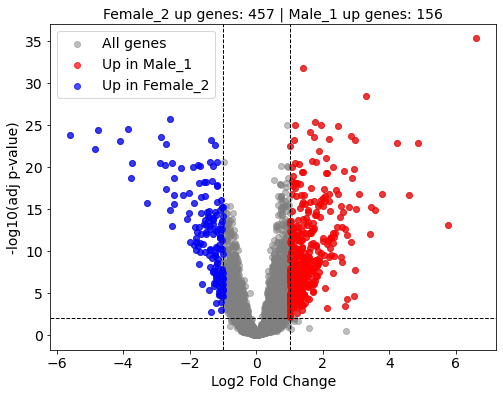

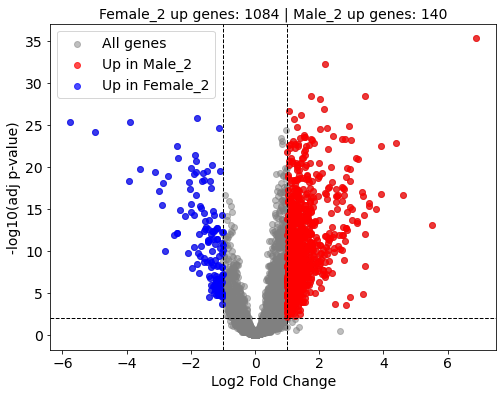

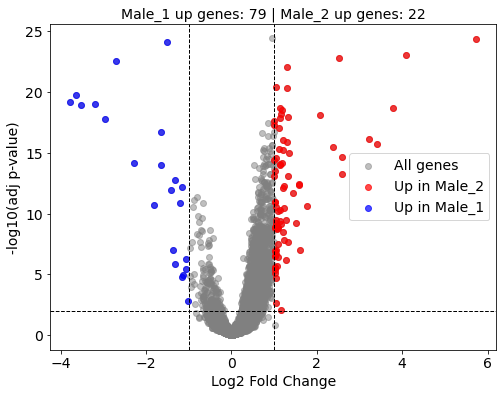

In [22]:
# Set significance threshold
pval_thresh = 0.01
logfc_thresh = 1  

# Dictionary to store upregulated genes for each comparison
up_genes_dict = {}

# Loop over all pairwise comparisons
for (m1, m2) in pairwise_combos:
    pair_df = results_df[(results_df['Muscle1'] == m1) & (results_df['Muscle2'] == m2)]
    
    # Identify upregulated and downregulated genes
    sig_up = pair_df[(pair_df['adj_pvalue'] < pval_thresh) & (pair_df['Log2FC'] > logfc_thresh)]
    sig_down = pair_df[(pair_df['adj_pvalue'] < pval_thresh) & (pair_df['Log2FC'] < -logfc_thresh)]
    
    # Count of up genes for each muscle
    m1_up_count = len(sig_up)   # log2FC > 0 → up in Muscle1
    m2_up_count = len(sig_down)     # log2FC < 0 → up in Muscle2
    
    # Store the genes in dictionary
    up_genes_dict[f'Up in {m1} vs {m2}'] = set(sig_down['Gene'])
    up_genes_dict[f'Up in {m2} vs {m1}'] = set(sig_up['Gene'])
    
    # Volcano plot
    plt.figure(figsize=(8,6))
    plt.scatter(pair_df['Log2FC'], -np.log10(pair_df['adj_pvalue']), color='grey', alpha=0.5, label='All genes')
    plt.scatter(sig_up['Log2FC'], -np.log10(sig_up['adj_pvalue']), color='red', alpha=0.7, label=f'Up in {m2}')
    plt.scatter(sig_down['Log2FC'], -np.log10(sig_down['adj_pvalue']), color='blue', alpha=0.7, label=f'Up in {m1}')
    
    # Threshold lines
    plt.axhline(-np.log10(pval_thresh), color='black', linestyle='--', linewidth=1)
    plt.axvline(logfc_thresh, color='black', linestyle='--', linewidth=1)
    plt.axvline(-logfc_thresh, color='black', linestyle='--', linewidth=1)
    
    # Legend with fontsize fix
    leg = plt.legend(fontsize=14)  # ensures legend labels are size 14
    plt.setp(leg.get_title(), fontsize=14)  # ensures legend title (if any) is also size 14

    # Tick labels fontsize
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    # Updated title
    plt.title(f'{m1} up genes: {m1_up_count} | {m2} up genes: {m2_up_count}', fontsize=14)
    plt.xlabel('Log2 Fold Change', fontsize=14)
    plt.ylabel('-log10(adj p-value)', fontsize=14)
    plt.show()

In [1]:
# Set significance threshold
pval_thresh = 0.01
logfc_thresh = 1  

# Dictionary to store upregulated genes for each comparison
up_genes_dict = {}

# Loop over all pairwise comparisons
for (m1, m2) in pairwise_combos:
    pair_df = results_df[(results_df['Muscle1'] == m1) & (results_df['Muscle2'] == m2)]
    pair_df = pair_df.set_index('Gene')
    
    # Identify upregulated and downregulated genes
    sig_up = pair_df[(pair_df['adj_pvalue'] < pval_thresh) & (pair_df['Log2FC'] > logfc_thresh)]
    sig_down = pair_df[(pair_df['adj_pvalue'] < pval_thresh) & (pair_df['Log2FC'] < -logfc_thresh)]
    
    # Count of up genes for each muscle
    m1_up_count = len(sig_up)   # log2FC > 0 → up in Muscle1
    m2_up_count = len(sig_down)     # log2FC < 0 → up in Muscle2
    
    # Store the genes in dictionary
    up_genes_dict[f'Up in {m1} vs {m2}'] = set(sig_up.index)
    up_genes_dict[f'Up in {m2} vs {m1}'] = set(sig_down.index)
    
    # Volcano plot
    plt.figure(figsize=(4,3))
    plt.scatter(pair_df['Log2FC'], -np.log10(pair_df['adj_pvalue']), color='grey', s=10, alpha=0.5, label='All genes', rasterized=True)
    plt.scatter(sig_up['Log2FC'], -np.log10(sig_up['adj_pvalue']), color='red', s=10, alpha=0.7, label=f'Up in {m1}', rasterized=True)
    plt.scatter(sig_down['Log2FC'], -np.log10(sig_down['adj_pvalue']), color='blue', s=10, alpha=0.7, label=f'Up in {m2}', rasterized=True)
    
    # Threshold lines
    plt.axhline(-np.log10(pval_thresh), color='black', linestyle='--', linewidth=1)
    plt.axvline(logfc_thresh, color='black', linestyle='--', linewidth=1)
    plt.axvline(-logfc_thresh, color='black', linestyle='--', linewidth=1)
    
    # Legend with fontsize fix
    leg = plt.legend(
        fontsize=14)
    plt.setp(leg.get_title(), fontsize=14)  # ensures legend title (if any) is also size 14

    # Tick labels fontsize
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    # Updated title
    plt.title(f'{m1} up genes: {m1_up_count} | {m2} up genes: {m2_up_count}', fontsize=14)
    plt.xlabel('Log2 Fold Change', fontsize=14)
    plt.ylabel('-log10(adj p-value)', fontsize=14)
    
    # >>> ADD YOUR ANNOTATION CODE HERE for Male <<<
    genes_to_label = ["Pkm", 'Kdm5d']  # <-- your custom list

    for idx, row in pair_df.iterrows():
        gene_name = idx.split("_")[1]
        if gene_name in genes_to_label:
            x = row['Log2FC']
            y = -np.log10(row['adj_pvalue'])

            # Annotate with arrow
            plt.annotate(
                gene_name,
                xy=(x, y),                     # point
                xytext=(x - 3, y + 1),     # label position offset
                fontsize=14,
                fontstyle='italic',
                #fontweight='bold',
                arrowprops=dict(
                    arrowstyle="-|>",
                    lw=1.2,
                    color='black'
                )
        )
    
    # >>> ADD YOUR ANNOTATION CODE HERE for Female <<<
    genes_to_label = ["Myh2", "Myh1", 'Gsk3a', 'Setd2', 'Bmyc']  # <-- your custom list

    for idx, row in pair_df.iterrows():
        gene_name = idx.split("_")[1]
        if gene_name in genes_to_label:
            x = row['Log2FC']
            y = -np.log10(row['adj_pvalue'])

            # Annotate with arrow
            plt.annotate(
                gene_name,
                xy=(x, y),                     # point
                xytext=(x + 2, y + 1),     # label position offset
                fontsize=14,
                fontstyle='italic',
                #fontweight='bold',
                arrowprops=dict(
                    arrowstyle="-|>",
                    lw=1.2,
                    color='black'
                )
        )
    plt.rcParams['svg.fonttype'] = 'none'
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["font.size"] = 14
    plt.savefig(f'DEG {m1} vs {m2}.svg', format='svg', dpi=300, bbox_inches='tight') 
            
    plt.show()

NameError: name 'pairwise_combos' is not defined

In [24]:
for index in results_df.index:
    if 'Myh2_' in results_df.loc[index]['Gene']:
        print(results_df.loc[index])

Gene          ENSMUSG00000033196_Myh2_ProteinCoding
Muscle1                                    Female_1
Muscle2                                    Female_2
Log2FC                                      0.17549
pvalue                                     0.204216
adj_pvalue                                 0.453998
Name: 8458, dtype: object
Gene          ENSMUSG00000033196_Myh2_ProteinCoding
Muscle1                                    Female_1
Muscle2                                      Male_1
Log2FC                                     1.731759
pvalue                                          0.0
adj_pvalue                                      0.0
Name: 28867, dtype: object
Gene          ENSMUSG00000033196_Myh2_ProteinCoding
Muscle1                                    Female_1
Muscle2                                      Male_2
Log2FC                                     2.710057
pvalue                                          0.0
adj_pvalue                                      0.0
Name: 49421

In [23]:
with open("DEG_MvsF.txt", "w") as f:
    f.write(str(up_genes_dict))

In [24]:
# Create dictionary of sets for the 4 Male vs Female comparisons
male_up_samples = {
    'M1 vs F1': up_genes_dict['Up in Male_1 vs Female_1'],
    'M1 vs F2': up_genes_dict['Up in Male_1 vs Female_2'],
    'M2 vs F1': up_genes_dict['Up in Male_2 vs Female_1'],
    'M2 vs F2': up_genes_dict['Up in Male_2 vs Female_2']
}

# Plot Venn diagram
venn(male_up_samples)
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 7
plt.title('Genes Up in Male vs Females')
plt.savefig('Venn_Male_up_genes.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Optional: show percentages
venn(male_up_samples, fmt="{percentage:.1f}%")
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 7
plt.title('Genes Up in Male vs Females (%)')
plt.savefig('Venn_Male_up_genes_percent.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


/var/folders/mg/6wjwkry15y79vlj0f727ljh40000gq/T/ipykernel_43790/1837300178.py:16: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()
/var/folders/mg/6wjwkry15y79vlj0f727ljh40000gq/T/ipykernel_43790/1837300178.py:26: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


In [25]:
# Create dictionary of sets for the 4 Male vs Female comparisons
female_up_samples = {
    'F1 vs M1': up_genes_dict['Up in Female_1 vs Male_1'],
    'F1 vs M2': up_genes_dict['Up in Female_1 vs Male_2'],
    'F2 vs M1': up_genes_dict['Up in Female_2 vs Male_1'],
    'F2 vs M2': up_genes_dict['Up in Female_2 vs Male_2']
}

# Plot Venn diagram
venn(female_up_samples)
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 7
plt.title('Genes Up in Female vs Males')
plt.savefig('Venn_Female_up_genes.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Optional: show percentages
venn(female_up_samples, fmt="{percentage:.1f}%")
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 7
plt.title('Genes Up in Female vs Males (%)')
plt.savefig('Venn_Female_up_genes_percent.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


/var/folders/mg/6wjwkry15y79vlj0f727ljh40000gq/T/ipykernel_43790/892464975.py:16: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()
/var/folders/mg/6wjwkry15y79vlj0f727ljh40000gq/T/ipykernel_43790/892464975.py:26: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()
